In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model_hybrid as model

In [2]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10
trauma_rewards = default_rewards.copy()
trauma_rewards[0] = -100

In [ ]:
environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
agent = model.HybridAgent(environment, bias=0.1)
test = model.Simulator(agent, environment)
test.run(100, 100, time=10, print_message=True, delta=20, a=0.1, visualize=True)
for trial in test.record:
    print(len(trial))
test.network.visualize(min_strength=1)
data = test.network.group_activation()
xs = [0, 0, 0, 0] + list(data.keys())[:101]
ys = list(data.values())
sns.relplot(x=xs, y=ys, kind="scatter")
plt.show()

In [5]:
def run_experiment(
    # Environment parameters
    n=100,
    groups=5,
    rewards=None,
    thres=0,
    in_group=10,
    trauma=(0, 10),
    # Simulator / decay parameters
    runs=50,
    max_steps=100,
    time=10,
    delta=20,
    a=0.1,
    # Agent parameters (HybridAgent)
    alpha=0.1,
    gamma=0.9,
    temp=0.1,
    bias=0.5,
    # Repetitions for averaging
    rep=10,
):
    """
    Run the hybrid agent experiment with the given parameters and return
    average and final retrieval lengths across `rep` repetitions.

    Parameters
    ----------
    n : int
        Number of memories.
    groups : int
        Number of groups.
    rewards : dict or None
        Reward mapping {node_index: reward}. If None, defaults to all 1s
        with the trauma node (trauma[0]) set to -100.
    thres : float
        Spreading-activation threshold; activations below this are zeroed.
    in_group : float
        Base weight for within-group edges.
    trauma : tuple
        (trauma_node_index, trauma_activation_boost).
    runs : int
        Number of retrieval episodes per repetition.
    max_steps : int
        Maximum steps per retrieval episode.
    time : float
        Decay time added to traces after each retrieval (controls forgetting rate).
    delta : int or None
        Number of additional memories added after each retrieval. None = no addition.
    a : float
        Initial activation value for newly added memories.
    connectivity : float or None
        Noise sigma for spreading activation (Memory.sigma). Uses model default if None.
    alpha : float
        Agent learning rate.
    gamma : float
        Agent discount factor.
    temp : float
        Softmax temperature for the recall decision gate.
    bias : float
        HybridAgent mixing weight: 0 = pure QAgent, 1 = pure Agent.
    rep : int
        Number of independent repetitions to average over.

    Returns
    -------
    dict with keys:
        "avg_retrieval_length"   : float  — mean of per-rep average retrieval lengths
        "final_retrieval_length" : float  — mean of per-rep final retrieval lengths
    """
    rep_avg = []
    rep_final = []

    for _ in range(rep):
        # Build default rewards if not provided
        if rewards is None:
            r = {i: 1 for i in range(n)}
            if trauma[0] is not None:
                r[trauma[0]] = -100
        else:
            r = rewards

        # Construct environment
        env_kwargs = dict(thres=thres, in_group=in_group, trauma=trauma)
        environment = model.Memory(n, groups, r, **env_kwargs)

        # Construct agent
        agent = model.HybridAgent(
            environment, alpha=alpha, gamma=gamma, temp=temp, bias=bias
        )

        # Run simulation
        sim = model.Simulator(agent, environment)
        sim.run(runs, max_steps, time=time, delta=delta, a=a)

        retrieval_lengths = [len(trial) for trial in sim.record]
        rep_avg.append(np.mean(retrieval_lengths))
        rep_final.append(retrieval_lengths[-1])

    return {
        "avg_retrieval_length": float(np.mean(rep_avg)),
        "final_retrieval_length": float(np.mean(rep_final)),
    }

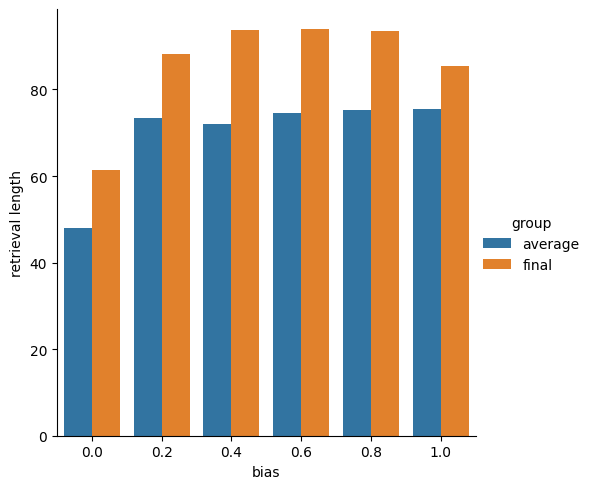

In [7]:
data = []
for bias in [0, 0.2, 0.4, 0.6, 0.8, 1]:
    result = run_experiment(bias=bias, rep=10)
    data.append({"bias": bias, "retrieval length": result["avg_retrieval_length"], "group": "average"})
    data.append({"bias": bias, "retrieval length": result["final_retrieval_length"], "group": "final"})
sns.catplot(data=pd.DataFrame(data), x="bias", y="retrieval length", hue="group", kind="bar")
plt.show()

# Experiment 3: Bias

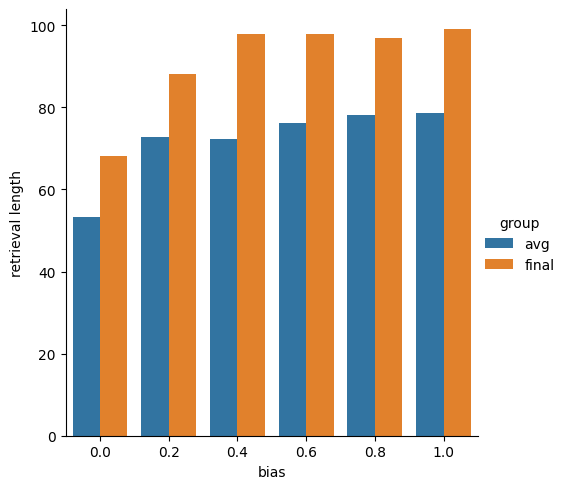

In [4]:
def exp_3(params, n, rep=10):
    data = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
            agent = model.HybridAgent(environment, bias=p)
            test = model.Simulator(agent, environment)
            test.run(n, 100, time=10, delta=20, a=0.1)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        data.append({"bias": p, "retrieval length": np.mean(rep_avg), "group": "avg"})
        data.append({"bias": p, "retrieval length": np.mean(rep_final), "group": "final"})
    return data


params = [i / 5 for i in range(6)]
data = exp_3(params, 50)
sns.catplot(data=pd.DataFrame(data), x="bias", y="retrieval length", hue="group", kind="bar")
plt.show()

In [ ]:
def exp_1(opt, params, n, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, 5, default_rewards, trauma=(0, 1))
            if opt == "alpha":
                agent = model.QAgent(environment, alpha=p)
            elif opt == "gamma":
                agent = model.QAgent(environment, gamma=p)
            elif opt == "temp":
                agent = model.QAgent(environment, temp=p)
            test = model.Simulator(agent, environment)
            test.run(n, 100, time=50, delta=20, a=1)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=1)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

# Experiment 2: Environment Parameters

- Number of memories
- Number of groups
- Connectivity
- Rewards
- Trauma Activation
- Decay
- Delta (Additional Memories Presented)

In [ ]:
def exp_2(n, groups, max_length, runs=100, time=0.1, rewards=None, t_a=1):
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards, trauma=(0, t_a))
    agent = model.Agent()
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time, delta=20, a=1)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

In [ ]:
def qexp_2(n, groups, max_length, runs=100, time=0.1, rewards=None, t_a=1):
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards, trauma=(0, t_a))
    agent = model.QAgent(environment)
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time, delta=20, a=1)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = qexp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = qexp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = exp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = qexp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = exp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = qexp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t_a in [10, 20, 50, 80]:
    lengths = exp_2(n, groups, max_length=n - 1, t_a=t_a)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"trauma": t_a, "type": "average", "value": avg / n})
    data.append({"trauma": t_a, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="trauma", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t_a in [10, 20, 50, 80]:
    lengths = qexp_2(n, groups, max_length=n - 1, t_a=t_a)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"trauma": t_a, "type": "average", "value": avg / n})
    data.append({"trauma": t_a, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="trauma", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
trauma_rewards = default_rewards.copy()
trauma_rewards[0] = -100
environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
agent = model.QAgent(environment)
test = model.Simulator(agent, environment)
test.run(100, 100, time=10, print_message=True, delta=20, a=0.1)
for trial in test.record:
    print(len(trial))
test.network.visualize(min_strength=1)
data = test.network.group_activation()
xs = [0, 0, 0, 0] + list(data.keys())[:101]
ys = list(data.values())
sns.relplot(x=xs, y=ys, kind="scatter")
plt.show()

In [ ]:
def exp_1(opt, params, runs, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
            if opt == "alpha":
                agent = model.QAgent(environment, alpha=p)
            elif opt == "gamma":
                agent = model.QAgent(environment, gamma=p)
            elif opt == "temp":
                agent = model.QAgent(environment, temp=p)
            test = model.Simulator(agent, environment)
            test.run(runs, 100, time=10, print_message=True, delta=20, a=0.1)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=1)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()